In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [3]:
import OscTools as osc
from OscTools import sbn_tools as sbn
from OscTools import apps
from OscTools import const
from OscTools.sterile_tools import Sterile


# Example of using SBN class to plot rates and calculate chi2

In [35]:
exp_test = sbn.SBN(Emin=0.01)
exp_test_nodis = sbn.SBN(Emin=0.01, disappearance=False, nbins=60)

sterile_params={'g': 1e-5,
 'm4': np.sqrt(10),
 'Ue4Sq': 0.1,
 'Um4Sq': 0.1}
 
sterile = Sterile(
        sterile_params,
        oscillations=True,
        decay=False,
        decouple_decay=False,
    )


In [38]:
np.savetxt('frac_mig_matrix_for_pedro.txt', exp_test.build_frac_covariance_matrix())

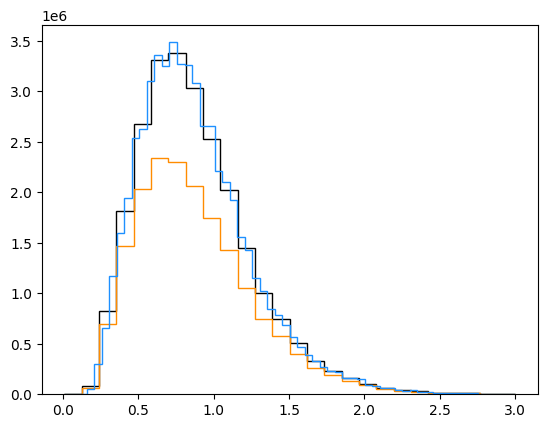

In [27]:

h =plt.hist(exp_test.Ereco_bin_center, bins=exp_test.Ereco_bins, weights=exp_test.reco_unosc_numu_rate_SBND(), histtype='step', color='black')
h =plt.hist(exp_test.Ereco_bin_center, bins=exp_test.Ereco_bins, weights=exp_test.reco_osc_numu_rate_SBND(sterile), histtype='step', color='darkorange')
h =plt.hist(exp_test_nodis.Ereco_bin_center, bins=exp_test_nodis.Ereco_bins, weights=exp_test_nodis.reco_osc_numu_rate_SBND(sterile), histtype='step', color='dodgerblue')

# _=plt.hist(exp_test.Ereco_bin_center, bins=exp_test.Ereco_bins, weights=exp_test.reco_unosc_nue_rate_ICARUS(), histtype='step', color='black')
# _=plt.hist(exp_test.Ereco_bin_center, bins=exp_test.Ereco_bins, weights=exp_test.reco_osc_nue_rate_ICARUS(sterile), histtype='step', color='darkorange')

# _=plt.hist(exp_test.Ereco_bin_center, bins=exp_test.Ereco_bins, weights=exp_test.reco_osc_numu_rate_SBND(sterile), histtype='step')
# _=plt.hist(exp_test.Ereco_bin_center, bins=exp_test.Ereco_bins, weights=exp_test.reco_osc_nue_rate_ICARUS(sterile), histtype='step')
# _=plt.hist(exp_test.Ereco_bin_center, bins=exp_test.Ereco_bins, weights=exp_test.reco_osc_numu_rate_ICARUS(sterile), histtype='step')
# plt.ylim(1e2,1e7)
# plt.semilogy()


In [31]:
(h[0]*np.diff(h[1])).sum()/exp_test_nodis.Ntotal_numu_SBND

np.float64(0.9999999999999997)

## All of the below are the steps I took to build the SBN class:

### Make sure the fluxes at SBND, Mini, Micro, and ICARUS are ok

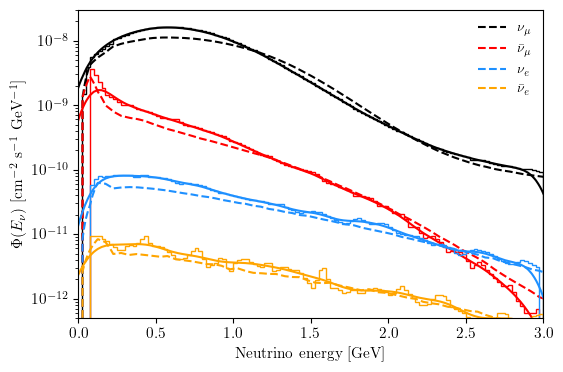

In [2000]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

e, *f = np.genfromtxt("OscTools/include/fluxes/MiniBooNE_FHC.dat", skip_header=1, unpack=True)
flux_numu = interp1d(e, f[1], kind="linear", fill_value=0.0, bounds_error=False)
flux_numubar = interp1d(e, f[4], kind="linear", fill_value=0.0, bounds_error=False)
flux_nue = interp1d(e, f[0], kind="linear", fill_value=0.0, bounds_error=False)
flux_nuebar = interp1d(e, f[3], kind="linear", fill_value=0.0, bounds_error=False)

# Apply Gaussian smoothing to the ydata points
e, *f = np.genfromtxt("OscTools/include/fluxes/SBND_FHC.dat", skip_header=1, unpack=True)
flux_numu_SBND = interp1d(e, gaussian_filter1d(f[1], sigma=3, mode='nearest'), kind="linear", fill_value=0.0, bounds_error=False)
flux_numubar_SBND = interp1d(e, gaussian_filter1d(f[4], sigma=3, mode='nearest'), kind="linear", fill_value=0.0, bounds_error=False)
flux_nue_SBND = interp1d(e, gaussian_filter1d(f[0], sigma=3, mode='nearest'), kind="linear", fill_value=0.0, bounds_error=False)
flux_nuebar_SBND = interp1d(e, gaussian_filter1d(f[3], sigma=4, mode='nearest'), kind="linear", fill_value=0.0, bounds_error=False)


def flux(E, detector, nuflavor):
    if nuflavor == "numu":
        if detector == "SBND":
            return flux_numu_SBND(E)
        elif detector == "ICARUS":
            return flux_numu(E) * (osc.L_mini/osc.L_ICARUS)**2
        else:
            raise ValueError(f"Detector {detector} not recognized")
    elif nuflavor == "nue":
        if detector == "SBND":
            return flux_nue_SBND(E)
        elif detector == "ICARUS":
            return flux_nue(E) * (osc.L_mini/osc.L_ICARUS)**2 
        else:
            raise ValueError(f"Detector {detector} not recognized")
    elif nuflavor == "nuebar":
        if detector == "SBND":
            return flux_nuebar_SBND(E)
        elif detector == "ICARUS":
            return flux_nuebar(E) * (osc.L_mini/osc.L_ICARUS)**2
        else:
            raise ValueError(f"Detector {detector} not recognized")
    elif nuflavor == "numubar":
        if detector == "SBND":
            return flux_numubar_SBND(E)
        elif detector == "ICARUS":
            return flux_numubar(E) * (osc.L_mini/osc.L_ICARUS)**2
        else:
            raise ValueError(f"Detector {detector} not recognized")
        

E = np.linspace(0, 3, 1000)
ax.plot(E, flux(E,'SBND','numu'), ls='-', color='black')
ax.hist(e, bins=np.append(e,[e.max()+0.0125]), weights=f[1], ls='-', color='black', histtype='step', lw=1)
# ax.plot(E, flux(E,'ICARUS','numu')*(osc.L_ICARUS/osc.L_SBND)**2, ls=':', color='black')
ax.plot(E, flux_numu(E)*(osc.L_mini/osc.L_SBND)**2, ls='--', color='black', label=r'$\nu_\mu$')

ax.plot(E, flux(E,'SBND','numubar'), ls='-', color='red')
ax.hist(e, bins=np.append(e,[e.max()+0.0125]), weights=f[4], ls='-', color='red', histtype='step', lw=1)
# ax.plot(E, flux(E,'ICARUS','numubar')*(osc.L_ICARUS/osc.L_SBND)**2, ls=':', color='red')
ax.plot(E, flux_numubar(E)*(osc.L_mini/osc.L_SBND)**2, ls='--', color='red', label=r'$\bar\nu_\mu$')

ax.plot(E, flux(E,'SBND','nue'), ls='-', color='dodgerblue')
ax.hist(e, bins=np.append(e,[e.max()+0.0125]), weights=f[0], ls='-', color='dodgerblue', histtype='step', lw=1)
# ax.plot(E, flux(E,'ICARUS','nue')*(osc.L_ICARUS/osc.L_SBND)**2, ls=':', color='dodgerblue')
ax.plot(E, flux_nue(E)*(osc.L_mini/osc.L_SBND)**2, ls='--', color='dodgerblue', label=r'$\nu_e$')

ax.plot(E, flux(E,'SBND','nuebar'), ls='-', color='orange')
ax.hist(e, bins=np.append(e,[e.max()+0.0125]), weights=f[3], ls='-', color='orange', histtype='step', lw=1)
# ax.plot(E, flux(E,'ICARUS','nuebar')*(osc.L_ICARUS/osc.L_SBND)**2, ls=':', color='orange')
ax.plot(E, flux_nuebar(E)*(osc.L_mini/osc.L_SBND)**2, ls='--', color='orange', label=r'$\bar\nu_e$')

ax.legend()
plt.xlim(0,3)
plt.ylim(5e-13, 3e-8)
ax.set_xlabel(r'Neutrino energy [GeV]')
ax.set_ylabel(r'$\Phi(E_\nu)$ [cm$^{-2}$ s$^{-1}$ GeV$^{-1}$]')
plt.semilogy()
plt.savefig('plots/SBN_fluxes.pdf')

## Import xsecs from GENIE spline files

In [1161]:
import xml.etree.ElementTree as ET

def parse_xsec_spline(file_path):
    """
    Parses an XML file containing GENIE cross-section spline data
    and extracts energy (E) and cross-section (xsec) values into a dictionary.

    :param file_path: Path to the XML file
    :return: Dictionary containing energy and cross-section arrays
    """
    tree = ET.parse(file_path)
    root = tree.getroot()

    # Dictionary to store data
    xsec_data = {}

    # Iterate over splines
    for spline in root.findall(".//spline"):
        spline_name = spline.get("name")  # Extract spline name
        energies = []
        xsecs = []

        # Extract knots (E and xsec values)
        for knot in spline.findall("knot"):
            energy = float(knot.find("E").text.strip())
            xsec = float(knot.find("xsec").text.strip())
            energies.append(energy)
            xsecs.append(xsec)

        # Store in dictionary
        xsec_data[spline_name] = {"energies": np.array(energies), "xsec": np.array(xsecs)}

    return xsec_data

# Example usage
file_path = "/Users/mhostert/Downloads/genie_xsec 2/v3_00_04_ub2/NULL/G1810a0211a-k250-e1000/data/gxspl-FNALsmall.xml"  # Replace with actual file path
# file_path = "/Users/mhostert/Downloads/genie_xsec 2/v3_00_04_ub2/NULL/G1810a0211a-k250-e1000/data/gxspl-freenuc.xml"  # Replace with actual file path
xsec_dict = parse_xsec_spline(file_path)

# Print sample output
for spline, data in xsec_dict.items():
    print(f"Spline: {spline}")
    print(f"First 5 Energies: {data['energies'][:5]}")
    print(f"First 5 Xsecs: {data['xsec'][:5]}\n")

Spline: genie::AhrensNCELPXSec/Default/nu:-12;tgt:1000000010;N:2112;proc:Weak[NC],QES;
First 5 Energies: [0.01    0.01047 0.01097 0.01149 0.01203]
First 5 Xsecs: [3.59459370e-15 4.04625720e-15 4.53924351e-15 5.07725266e-15
 5.66429524e-15]

Spline: genie::AhrensNCELPXSec/Default/nu:-12;tgt:1000010010;N:2212;proc:Weak[NC],QES;
First 5 Energies: [0.01    0.01047 0.01097 0.01149 0.01203]
First 5 Xsecs: [4.96647904e-15 5.55870565e-15 6.20348370e-15 6.90570953e-15
 7.67068106e-15]

Spline: genie::AhrensNCELPXSec/Default/nu:-12;tgt:1000010020;N:2112;proc:Weak[NC],QES;
First 5 Energies: [0.01    0.01047 0.01097 0.01149 0.01203]
First 5 Xsecs: [1.59128138e-15 1.78992145e-15 2.00670431e-15 2.24335851e-15
 2.50180654e-15]

Spline: genie::AhrensNCELPXSec/Default/nu:-12;tgt:1000010020;N:2212;proc:Weak[NC],QES;
First 5 Energies: [0.01    0.01047 0.01097 0.01149 0.01203]
First 5 Xsecs: [2.19735507e-15 2.45750182e-15 2.74073603e-15 3.04937638e-15
 3.38600641e-15]

Spline: genie::AhrensNCELPXSec/Defau

In [1162]:
# xsec_type = 'NievesQELCCPXSec'
# xsec_nuebar = xsec_dict['genie::{xsec_type}//Dipole/nu:-12;tgt:1000010010;N:2212;proc:Weak[CC],QES;']
# xsec_nue = xsec_dict['genie::{xsec_type}/Dipole/nu:12;tgt:1000000010;N:2112;proc:Weak[CC],QES;']
# xsec_numubar = xsec_dict['genie::{xsec_type}/Dipole/nu:-14;tgt:1000010010;N:2212;proc:Weak[CC],QES;']
# xsec_numu = xsec_dict['genie::{xsec_type}/Dipole/nu:14;tgt:1000000010;N:2112;proc:Weak[CC],QES;']

Enu = np.linspace(0, 3, 1000)

temp_dict = xsec_dict[f'genie::NievesQELCCPXSec/Dipole/nu:12;tgt:1000180400;N:2112;proc:Weak[CC],QES;']
xsec_interp = interp1d(temp_dict['energies'], temp_dict['xsec'], fill_value=0.0, bounds_error=False)
xsec_nue_QEL={}
xsec_nue_QEL['energies'] = Enu
xsec_nue_QEL['xsec'] = xsec_interp(Enu) * const.invGeV2_to_cm2 / 40

temp_dict = xsec_dict[f'genie::NievesQELCCPXSec/Dipole/nu:14;tgt:1000180400;N:2112;proc:Weak[CC],QES;']
xsec_interp = interp1d(temp_dict['energies'], temp_dict['xsec'], fill_value=0.0, bounds_error=False)
xsec_numu_QEL={}
xsec_numu_QEL['energies'] = Enu
xsec_numu_QEL['xsec'] = xsec_interp(Enu)* const.invGeV2_to_cm2 / 40

temp_dict = xsec_dict[f'genie::NievesSimoVacasMECPXSec2016/Default/nu:12;tgt:1000180400;proc:Weak[CC],MEC;']
xsec_interp = interp1d(temp_dict['energies'], temp_dict['xsec'], fill_value=0.0, bounds_error=False)
xsec_nue_MEC={}
xsec_nue_MEC['energies'] = Enu
xsec_nue_MEC['xsec'] = xsec_interp(Enu)* const.invGeV2_to_cm2 / 40

temp_dict = xsec_dict[f'genie::NievesSimoVacasMECPXSec2016/Default/nu:14;tgt:1000180400;proc:Weak[CC],MEC;']
xsec_interp = interp1d(temp_dict['energies'], temp_dict['xsec'], fill_value=0.0, bounds_error=False)
xsec_numu_MEC={}
xsec_numu_MEC['energies'] = Enu
xsec_numu_MEC['xsec'] = xsec_interp(Enu)* const.invGeV2_to_cm2 / 40

xsec_nue_RES = {}
xsec_nue_RES['energies'] = Enu
xsec_nue_RES[f'xsec'] = 0*Enu
for spline, data in xsec_dict.items():
    if ('genie::BergerSehgalRESPXSec2014/NoPauliBlock/nu:12;tgt:1000180400' in spline) and ('proc:Weak[CC],RES;res' in spline):
        xsec_interp = interp1d(data['energies'], data['xsec'], fill_value=0.0, bounds_error=False)
        xsec_nue_RES[f'xsec'] += xsec_interp(Enu)* const.invGeV2_to_cm2 / 40
    
xsec_numu_RES = {}
xsec_numu_RES['energies'] = Enu
xsec_numu_RES[f'xsec'] = 0*Enu
for spline, data in xsec_dict.items():
    if ('genie::BergerSehgalRESPXSec2014/NoPauliBlock/nu:14;tgt:1000180400' in spline) and ('proc:Weak[CC],RES;res' in spline):
        xsec_interp = interp1d(data['energies'], data['xsec'], fill_value=0.0, bounds_error=False)
        xsec_numu_RES[f'xsec'] += xsec_interp(xsec_numu_RES['energies'])* const.invGeV2_to_cm2 / 40
    
xsec_nutau_RES = {}
xsec_nutau_RES['energies'] = Enu
xsec_nutau_RES[f'xsec'] = 0*Enu
for spline, data in xsec_dict.items():
    if ('genie::BergerSehgalRESPXSec2014/NoPauliBlock/nu:16;tgt:1000180400' in spline) and ('proc:Weak[CC],RES;res' in spline):
        xsec_interp = interp1d(data['energies'], data['xsec'], fill_value=0.0, bounds_error=False)
        xsec_nutau_RES[f'xsec'] += xsec_interp(xsec_nutau_RES['energies'])* const.invGeV2_to_cm2 / 40

xsec_nue_DIS = {}
xsec_nue_DIS['energies'] = Enu
xsec_nue_DIS[f'xsec'] = 0*Enu
for spline, data in xsec_dict.items():
    if ('genie::QPMDISPXSec/Default/nu:12;tgt:1000180400;' in spline) and ('proc:Weak[CC],DIS' in spline):
        xsec_interp = interp1d(data['energies'], data['xsec'], fill_value=0.0, bounds_error=False)
        xsec_nue_DIS[f'xsec'] += xsec_interp(xsec_nue_DIS['energies'])* const.invGeV2_to_cm2 / 40

xsec_numu_DIS = {}
xsec_numu_DIS['energies'] = Enu
xsec_numu_DIS[f'xsec'] = 0*Enu
for spline, data in xsec_dict.items():
    if ('genie::QPMDISPXSec/Default/nu:14;tgt:1000180400;' in spline) and ('proc:Weak[CC],DIS' in spline):
        xsec_interp = interp1d(data['energies'], data['xsec'], fill_value=0.0, bounds_error=False)
        xsec_numu_DIS[f'xsec'] += xsec_interp(xsec_numu_DIS['energies'])* const.invGeV2_to_cm2 / 40

temp_dict = xsec_dict[f'genie::BergerSehgalCOHPiPXSec2015/Default/nu:12;tgt:1000180400;proc:Weak[CC],COH;hmult:(p=0,n=0,pi+=1,pi-=0,pi0=0);']
xsec_interp = interp1d(temp_dict['energies'], temp_dict['xsec'], fill_value=0.0, bounds_error=False)
xsec_nue_cohpion={}
xsec_nue_cohpion['energies'] = Enu
xsec_nue_cohpion['xsec'] = xsec_interp(Enu)* const.invGeV2_to_cm2 / 40

temp_dict = xsec_dict[f'genie::BergerSehgalCOHPiPXSec2015/Default/nu:14;tgt:1000180400;proc:Weak[CC],COH;hmult:(p=0,n=0,pi+=1,pi-=0,pi0=0);']
xsec_interp = interp1d(temp_dict['energies'], temp_dict['xsec'], fill_value=0.0, bounds_error=False)
xsec_numu_cohpion={}
xsec_numu_cohpion['energies'] = Enu
xsec_numu_cohpion['xsec'] = xsec_interp(Enu)* const.invGeV2_to_cm2 / 40


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_95827/3244355392.py:14: RuntimeWarning: invalid value encountered in divide
  ax.plot(Enu, (xsec_nue_QEL['xsec'] + xsec_nue_MEC['xsec'] + xsec_nue_RES['xsec'] + xsec_nue_DIS['xsec'] + xsec_nue_cohpion['xsec'])/Enu, color=color_nue, label='total')
/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_95827/3244355392.py:15: RuntimeWarning: invalid value encountered in divide
  ax.plot(Enu, (xsec_numu_QEL['xsec'] + xsec_numu_MEC['xsec'] + xsec_numu_RES['xsec'] + xsec_numu_DIS['xsec'] + xsec_numu_cohpion['xsec'])/Enu, color=color_numu)
/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_95827/3244355392.py:16: RuntimeWarning: invalid value encountered in divide
  ax.plot(Enu, xsec_nue_QEL['xsec']/Enu, ls=(1,(6,1.5)), color=color_nue, label='QEL')
/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_95827/3244355392.py:17: RuntimeWarning: invalid value encountered in divide
  ax.plot(Enu, xsec_numu_QEL['xsec']/Enu

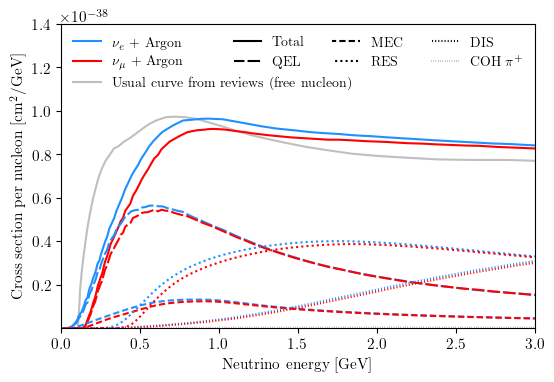

In [1163]:
from OscTools import plot_tools as pt

fig, ax = pt.std_fig(figsize=(6,4))
# ## Check cross sections
e, xsec = np.genfromtxt("OscTools/include/miniboone_eff/xsec.dat", skip_header=1, unpack=True)
xsec_numu = interp1d(e, xsec*e, kind="linear", fill_value=0.0, bounds_error=False)
xsec_nue = interp1d(e, xsec*e, kind="linear", fill_value=0.0, bounds_error=False)
plt.plot(e, xsec_numu(e)/e, ls='-', color='grey', alpha=0.5)
# plt.plot(e, xsec_nue(e)/e, ls='--', color='black')

color_nue = 'dodgerblue'
color_numu = 'red'

ax.plot(Enu, (xsec_nue_QEL['xsec'] + xsec_nue_MEC['xsec'] + xsec_nue_RES['xsec'] + xsec_nue_DIS['xsec'] + xsec_nue_cohpion['xsec'])/Enu, color=color_nue, label='total')
ax.plot(Enu, (xsec_numu_QEL['xsec'] + xsec_numu_MEC['xsec'] + xsec_numu_RES['xsec'] + xsec_numu_DIS['xsec'] + xsec_numu_cohpion['xsec'])/Enu, color=color_numu)
ax.plot(Enu, xsec_nue_QEL['xsec']/Enu, ls=(1,(6,1.5)), color=color_nue, label='QEL')
ax.plot(Enu, xsec_numu_QEL['xsec']/Enu, ls=(1,(6,1.5)), color=color_numu)
ax.plot(Enu, xsec_nue_MEC['xsec']/Enu, ls=(1,(3,1.5)), color=color_nue, label='MEC')
ax.plot(Enu, xsec_numu_MEC['xsec']/Enu, ls=(1,(3,1.5)), color=color_numu)
ax.plot(Enu, xsec_nue_RES['xsec']/Enu, ls=(1,(1,1.5)), color=color_nue, label='RES')
ax.plot(Enu, xsec_numu_RES['xsec']/Enu, ls=(1,(1,1.5)), color=color_numu)
ax.plot(Enu, xsec_nue_DIS['xsec']/Enu, ls=(1,(0.5,1)), color=color_nue, label='DIS')
ax.plot(Enu, xsec_numu_DIS['xsec']/Enu, ls=(1,(0.5,1)), color=color_numu)
ax.plot(Enu, xsec_nue_cohpion['xsec']/Enu, ls=(1,(0.1,1)), color=color_nue, label='COH $\pi^+$')
ax.plot(Enu, xsec_numu_cohpion['xsec']/Enu, ls=(1,(0.1,1)), color=color_numu)

# Create a new legend to clarify the difference between nue and numu
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], linestyle='-', color='black', label=r'Total'),
    Line2D([0], [0], linestyle=(1, (6, 1.5)), color='black', label=r'QEL'),
    Line2D([0], [0], linestyle=(1, (3, 1.5)), color='black', label=r'MEC'),
    Line2D([0], [0], linestyle=(1, (1, 1.5)), color='black', label=r'RES'),
    Line2D([0], [0], linestyle=(1, (0.5, 1)), color='black', label=r'DIS'),
    Line2D([0], [0], linestyle=(1, (0.1, 1)), color='black', label=r'COH $\pi^+$')
]
legend_elements_2 = [
    Line2D([0], [0], color=color_nue, label=r'$\nu_e$ + Argon'),
    Line2D([0], [0], color=color_numu, label=r'$\nu_\mu$ + Argon'),
    Line2D([0], [0], color='grey', alpha=0.5, label=r'Usual curve from reviews (free nucleon)'),
]
l1=ax.legend(handles=legend_elements, loc='upper right', ncol=3)
l2=ax.legend(handles=legend_elements_2, loc='upper left', ncol=1)
ax.add_artist(l1)
ax.set_xlabel('Neutrino energy [GeV]')
ax.set_ylabel('Cross section per nucleon [cm$^2$/GeV]')
ax.set_ylim(1e-41,1.4e-38)
ax.set_xlim(0,3)

# ax.set_yscale('log')

fig.savefig('plots/xsecs/xsecs.pdf', bbox_inches='tight', dpi=300)

In [2027]:
# Export to file
tot_xsec_nue = interp1d(Enu, (xsec_nue_QEL['xsec'] + xsec_nue_MEC['xsec'] + xsec_nue_RES['xsec'] + xsec_nue_DIS['xsec'] + xsec_nue_cohpion['xsec']), fill_value=0, bounds_error=False)
tot_xsec_numu = interp1d(Enu, (xsec_numu_QEL['xsec'] + xsec_numu_MEC['xsec'] + xsec_numu_RES['xsec'] + xsec_numu_DIS['xsec'] + xsec_numu_cohpion['xsec']), fill_value=0, bounds_error=False)

np.save('OscTools/include/GENIE_v3_muBtune2_tot_xsec_nue.npy', tot_xsec_nue)
np.save('OscTools/include/GENIE_v3_muBtune2_tot_xsec_numu.npy', tot_xsec_numu)

tot_xsec_nue = np.load("OscTools/include/GENIE_v3_muBtune2_tot_xsec_nue.npy", allow_pickle=True).item()
tot_xsec_numu = np.load("OscTools/include/GENIE_v3_muBtune2_tot_xsec_numu.npy", allow_pickle=True).item()
tot_xsec_nue(1)

array(9.62447389e-39)

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_95827/718799793.py:7: RuntimeWarning: invalid value encountered in divide
  ax.plot(Enu, xsec_tot_mu(Enu)/xsec_tot_e(Enu), color='black', label='ratio')


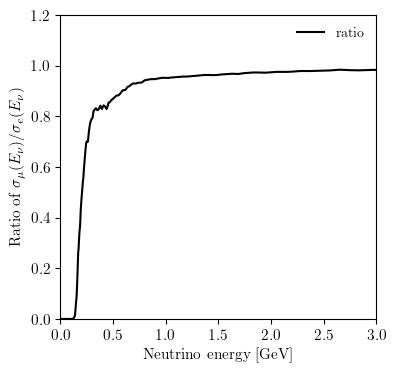

In [1164]:
fig, ax = pt.std_fig(figsize=(4,4))

tot_mu = (xsec_numu_QEL['xsec'] + xsec_numu_MEC['xsec'] + xsec_numu_RES['xsec'] + xsec_numu_DIS['xsec'] + xsec_numu_cohpion['xsec'])
xsec_tot_mu = interp1d(Enu, tot_mu, fill_value=0.0, bounds_error=False)
tot_e = (xsec_nue_QEL['xsec'] + xsec_nue_MEC['xsec'] + xsec_nue_RES['xsec'] + xsec_nue_DIS['xsec'] + xsec_nue_cohpion['xsec'])
xsec_tot_e = interp1d(Enu, tot_e, fill_value=0.0, bounds_error=False)
ax.plot(Enu, xsec_tot_mu(Enu)/xsec_tot_e(Enu), color='black', label='ratio')

ax.legend()
ax.set_xlim(0,3)
ax.set_ylim(0.0,1.2)
ax.set_xlabel('Neutrino energy [GeV]')
ax.set_ylabel(r'Ratio of $\sigma_{\mu}(E_\nu)/\sigma_e(E_\nu)$')
fig.savefig('plots/xsecs/xsec_ratio.pdf', bbox_inches='tight', dpi=300)

## Efficiencies

Using those from Wire-Cell paper

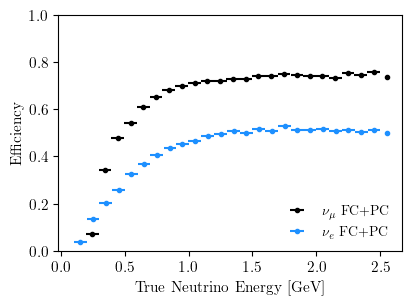

In [1521]:
e, eff = np.genfromtxt('OscTools/include/muB_data/inclusive_data/Efficiency_numuCC_PCplusFC_paper.dat', skip_header=1, unpack=True)
_=plt.errorbar(e, eff, xerr=np.append(np.diff(e)/2,[0]), label=r'$\nu_\mu$ FC+PC', fmt='.', color='black')
e, eff = np.genfromtxt('OscTools/include/muB_data/inclusive_data/Efficiency_nueCC_PCplusFC_paper.dat', skip_header=1, unpack=True)
_=plt.errorbar(e, eff, xerr=np.append(np.diff(e)/2,[0]), label=r'$\nu_e$ FC+PC', fmt='.', color='dodgerblue')
plt.xlabel('True Neutrino Energy [GeV]')
plt.ylabel('Efficiency')
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.savefig('plots/micro_efficiency.pdf', bbox_inches='tight', dpi=300)

# Build a smooth event rate interpolator

In [1304]:
exposure = 6.6e20 # POT
n_targets_SBND = (sbn.Mass_SBND / const.m_proton_in_t) # Nucleons (n or p+)
n_targets_ICARUS = (sbn.Mass_ICARUS / const.m_proton_in_t) # Nucleons (n or p+)

def numu_rate_SBND(E):
    return flux(E, "SBND", "numu") * n_targets_SBND * exposure * xsec_tot_mu(E)
def numu_rate_ICARUS(E):
    return flux(E, "ICARUS", "numu") * n_targets_ICARUS * exposure * xsec_tot_mu(E)

def nue_rate_SBND(E):
    return flux(E, "SBND", "nue") * n_targets_SBND * exposure * xsec_tot_mu(E)
def nue_rate_ICARUS(E):
    return flux(E, "ICARUS", "nue") * n_targets_ICARUS * exposure * xsec_tot_mu(E)

E = np.linspace(0.0, 3.0, 1000)
Ntotal_numu_SBND = (numu_rate_SBND(E) * np.diff(E)[0]).sum()
Ntotal_numu_ICARUS = (numu_rate_ICARUS(E) * np.diff(E)[0]).sum()

Ntotal_nue_SBND = (nue_rate_SBND(E) * np.diff(E)[0]).sum()
Ntotal_nue_ICARUS = (nue_rate_ICARUS(E) * np.diff(E)[0]).sum()

print(f"Total number of numu CC events in SBND: {Ntotal_numu_SBND:.3g}")
print(f"Total number of numu CC events in ICARUS: {Ntotal_numu_ICARUS:.3g}")

print(f"Total number of nue CC events in SBND: {Ntotal_nue_SBND:.3g}")
print(f"Total number of nue CC events in ICARUS: {Ntotal_nue_ICARUS:.3g}")

Total number of numu CC events in SBND: 4.04e+06
Total number of numu CC events in ICARUS: 5.19e+05
Total number of nue CC events in SBND: 2.75e+04
Total number of nue CC events in ICARUS: 3.21e+03


## Adding oscillation probabilities

In [1166]:
from OscTools.sterile_tools import Sterile

(0.0, 3.0)

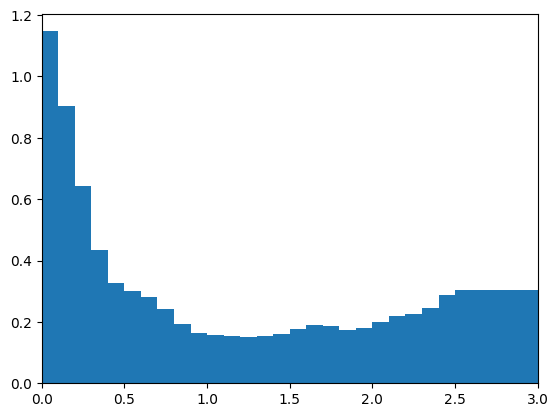

In [129]:
from OscTools import micro_tools as micro
from importlib.resources import files

other_bkg_FC = np.load(
    files(micro.muB_inclusive_datarelease_path)
    .joinpath(f"nueCC_FC_Bkg.npy")
    .open("rb")
)
intrinsic_bkg_FC = np.load(
    files(micro.muB_inclusive_datarelease_path)
    .joinpath(f"nueCC_FC_Sig.npy")
    .open("rb")
)

other_bkg_PC = np.load(
    files(micro.muB_inclusive_datarelease_path)
    .joinpath(f"nueCC_PC_Bkg.npy")
    .open("rb")
)
intrinsic_bkg_PC = np.load(
    files(micro.muB_inclusive_datarelease_path)
    .joinpath(f"nueCC_PC_Sig.npy")
    .open("rb")
)

other_bkg = other_bkg_FC + other_bkg_PC
intrinsic_bkg = intrinsic_bkg_FC + intrinsic_bkg_PC

from scipy.ndimage import gaussian_filter1d
other_bkg = gaussian_filter1d(other_bkg, sigma=1, mode="nearest")
intrinsic_bkg = gaussian_filter1d(intrinsic_bkg, sigma=1, mode="nearest")
other_bkg_ratio = interp1d(micro.BEdges0[:-1], other_bkg/intrinsic_bkg, fill_value=0.0, bounds_error=False)

plt.hist(micro.BEdges0[:-1], bins=micro.BEdges0, weights=other_bkg/intrinsic_bkg)
plt.xlim(0,3)

In [1560]:
sterile_params={'g': 0,
 'm4': np.sqrt(30),
 'Ue4Sq': 0.1,
 'Um4Sq': 0.01}
 
sterile = Sterile(
        sterile_params,
        oscillations=True,
        decay=False,
        decouple_decay=False,
    )


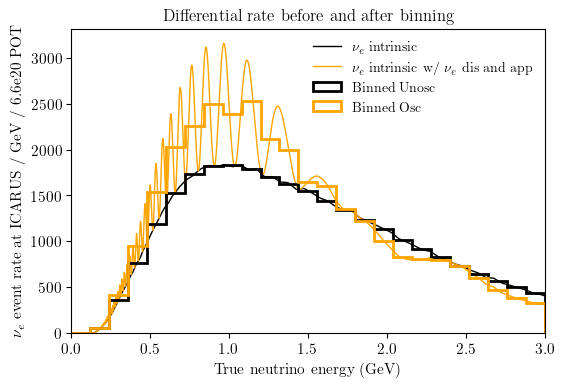

In [1561]:
fig, ax = pt.std_fig(figsize=(6,4))

E = np.linspace(0.01, 3.0, 10000)
ax.plot(E, nue_rate_ICARUS(E), color='black', lw=1, label=r'$\nu_e$ intrinsic')
ax.plot(E, nue_rate_ICARUS(E)*sterile.Peeosc(E, osc.L_ICARUS) + numu_rate_ICARUS(E)*sterile.Pmeosc(E, osc.L_ICARUS), color='orange', lw=1, label=r'$\nu_e$ intrinsic w/ $\nu_e$ dis and app')

bins = np.linspace(0, 3, 26)
h, be =np.histogram(E, weights=nue_rate_ICARUS(E)*np.diff(E)[0], bins=bins)
_=plt.hist(be[:-1], bins=be, weights=h/np.diff(be), histtype='step', color='black', lw=2, label='Binned Unosc')

h, be =np.histogram(E, weights=(nue_rate_ICARUS(E)*sterile.Peeosc(E, osc.L_ICARUS) + numu_rate_ICARUS(E)*sterile.Pmeosc(E, osc.L_ICARUS))*np.diff(E)[0], bins=bins)
_=plt.hist(be[:-1], bins=be, weights=h/np.diff(be), histtype='step', color='orange', lw=2, label='Binned Osc')

plt.ylabel(r'$\nu_e$ event rate at ICARUS / GeV / 6.6e20 POT')
plt.xlabel(r'True neutrino energy (GeV)')
plt.xlim(0,3)
plt.title('Differential rate before and after binning')
plt.legend()

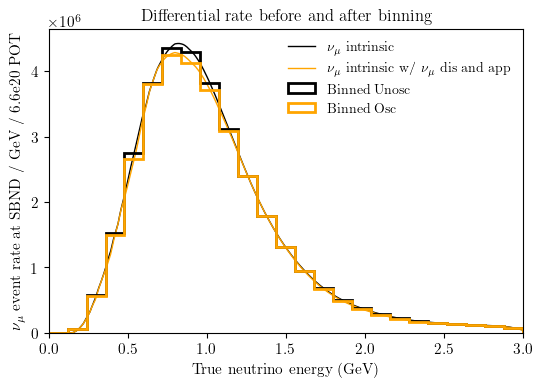

In [1566]:
fig, ax = pt.std_fig(figsize=(6,4))
sterile_params={'g': 0,
 'm4': np.sqrt(30),
 'Ue4Sq': 0.1,
 'Um4Sq': 0.01}
 
sterile = Sterile(
        sterile_params,
        oscillations=True,
        decay=False,
        decouple_decay=False,
    )



E = np.linspace(0.01, 3.0, 10000)
ax.plot(E, numu_rate_SBND(E), color='black', lw=1, label=r'$\nu_\mu$ intrinsic')
ax.plot(E, numu_rate_SBND(E)*sterile.Pmmosc(E, osc.L_SBND) + nue_rate_SBND(E)*sterile.Pmeosc(E, osc.L_SBND), color='orange', lw=1, label=r'$\nu_\mu$ intrinsic w/ $\nu_\mu$ dis and app')

bins = np.linspace(0, 3, 26)
h, be =np.histogram(E, weights=numu_rate_SBND(E)*np.diff(E)[0], bins=bins)
_=plt.hist(be[:-1], bins=be, weights=h/np.diff(be), histtype='step', color='black', lw=2, label='Binned Unosc')

h, be =np.histogram(E, weights=(numu_rate_SBND(E)*sterile.Pmmosc(E, osc.L_SBND) + nue_rate_ICARUS(E)*sterile.Pmeosc(E, osc.L_SBND))*np.diff(E)[0], bins=bins)
_=plt.hist(be[:-1], bins=be, weights=h/np.diff(be), histtype='step', color='orange', lw=2, label='Binned Osc')

plt.ylabel(r'$\nu_\mu$ event rate at SBND / GeV / 6.6e20 POT')
plt.xlabel(r'True neutrino energy (GeV)')
plt.xlim(0,3)
plt.title('Differential rate before and after binning')
plt.legend()

# Build smearing matrices:

In [1571]:
import numpy as np
from scipy.stats import crystalball
from scipy.integrate import quad

def build_smearing_matrix_crystal_ball(Emin, Emax, nbins, resolution=0.2, alpha=1.5, n=5):
    """
    Build a migration/smearing matrix for neutrino energies using
    a Crystal Ball function model with sigma = resolution * E_true.

    Parameters
    ----------
    Emin : float
        Minimum energy (GeV).
    Emax : float
        Maximum energy (GeV).
    nbins : int
        Number of bins (same for true and reco).
    resolution : float
        Fractional resolution (e.g. 0.2 means 20%).
    alpha : float
        Tail parameter of the Crystal Ball function.
    n : float
        Power-law exponent for the tail of the Crystal Ball function.

    Returns
    -------
    M : (nbins, nbins) ndarray
        Smearing matrix. M[i, j] = Probability of migrating from true bin i
        to reco bin j.
    bin_centers : (nbins,) ndarray
        Centers of the energy bins.
    bin_edges : (nbins+1,) ndarray
        Edges of the energy bins.
    """

    # Define bin edges and centers
    bin_edges = np.linspace(Emin, Emax, nbins + 1)
    bin_widths = np.diff(bin_edges)  # for integration range
    bin_centers = bin_edges[:-1] + bin_widths / 2

    # Prepare the smearing matrix
    M = np.zeros((nbins, nbins))

    # Build the matrix row by row: each row i corresponds to true energy bin i
    for i, E_true in enumerate(bin_centers):
        # Resolution sigma depends on E_true
        sigma = resolution * E_true

        # If E_true is very small, prevent sigma from being too small
        if sigma < 1e-12:
            sigma = 1e-12  

        # Define the Crystal Ball PDF for this E_true
        cb_pdf = lambda E_reco: crystalball.pdf(E_reco, beta=n, m=alpha, loc=E_true, scale=sigma)

        # Construct row i by integrating the Crystal Ball function over each reco bin
        for j, E_center in enumerate(bin_centers):
            E_low = bin_edges[j]
            E_high = bin_edges[j+1]

            # Integrate the Crystal Ball PDF over the bin range
            prob, _ = quad(cb_pdf, E_low, E_high)
            M[i, j] = prob

        # Normalize row i to sum to 1
        row_sum = M[i, :].sum()
        if row_sum > 0:
            M[i, :] /= row_sum

    return M.T, bin_centers, bin_edges

In [1572]:
from OscTools import micro_tools as micro

In [1750]:

import yaml
import pandas as pd

# Function to read the YAML file
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

# Function to process the YAML data
def process_data(data):
    # Extract dependent variable values
    dep_values = [item['value'] for item in data['dependent_variables'][0]['values']]
    
    # Extract independent variable values
    true_neutrino_energy = [item['value'] for item in data['independent_variables'][0]['values']]
    reco_neutrino_energy = [item['value'] for item in data['independent_variables'][1]['values']]

    # Create a DataFrame
    df = pd.DataFrame({
        'True Neutrino Energy Bin Index': true_neutrino_energy,
        'Reco Neutrino Energy Bin Index': reco_neutrino_energy,
        'Relative Number of Events': dep_values
    })
    
    return df


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_95827/570341460.py:33: RuntimeWarning: divide by zero encountered in log10
  c = ax.imshow(np.log10(M_interp), origin='lower', extent=(0, 3, 0, 3), aspect='auto')
/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_95827/570341460.py:33: RuntimeWarning: divide by zero encountered in log10
  c = ax.imshow(np.log10(M_interp), origin='lower', extent=(0, 3, 0, 3), aspect='auto')
/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_95827/570341460.py:33: RuntimeWarning: divide by zero encountered in log10
  c = ax.imshow(np.log10(M_interp), origin='lower', extent=(0, 3, 0, 3), aspect='auto')
/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_95827/570341460.py:62: RuntimeWarning: divide by zero encountered in log10
  c = ax.imshow(np.log10(M_small), origin='lower', extent=(Etrue_bins.min(), Etrue_bins.max(), Ereco_bins.min(), Etrue_bins.max()), aspect='auto')


10434101.561200917 23.999999999999996
22656787.089537006 24.0
88143.29251460916 25.0
49673.18751809601 24.0


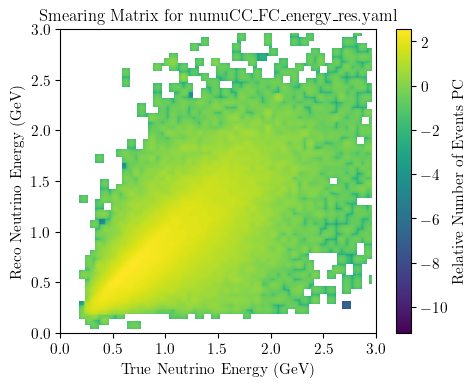

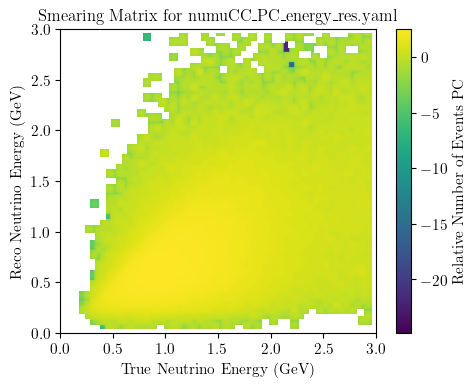

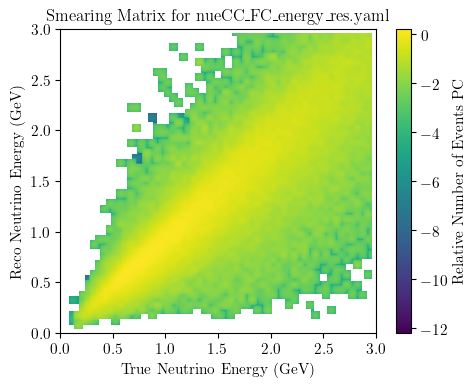

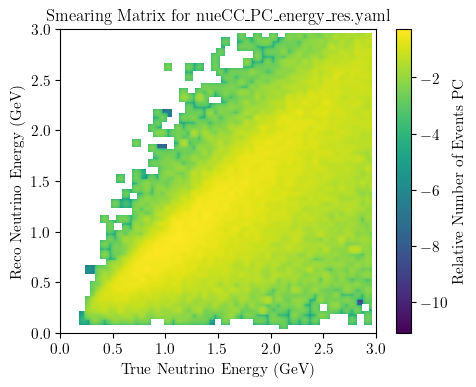

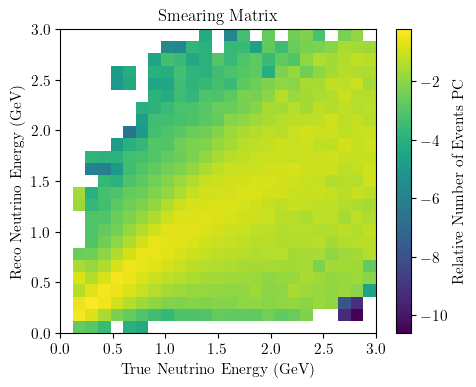

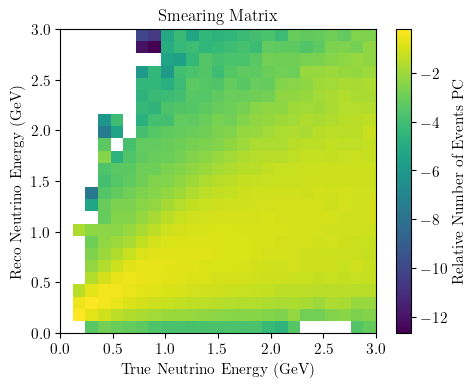

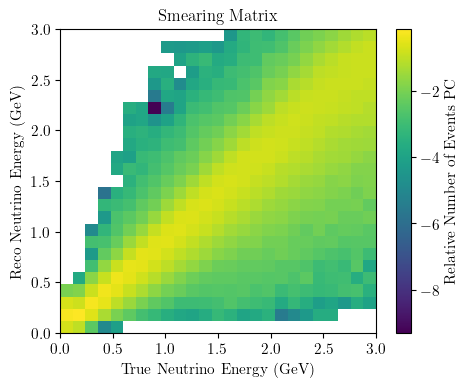

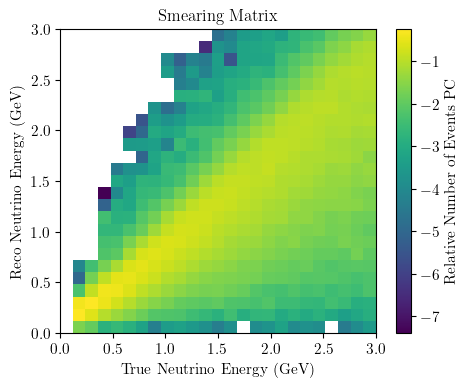

In [1991]:
from scipy.interpolate import RegularGridInterpolator

def create_refined_smearing_matrix(filename, nbins_refine=1_000, savefile=True, plot=True):

    # File path to the YAML file
    yaml_file = f'OscTools/include/muB_data/inclusive_data/DataRelease_v3/{filename}'  # Change this to the actual file path

    # Read and process the YAML data
    yaml_data = read_yaml(yaml_file)
    df = process_data(yaml_data)

    #  Load smearing matrix with 60 bins from 0 - 3 GeV (0.05 GeV bin width)
    Etruei = df['True Neutrino Energy Bin Index']
    Erecoi = df['Reco Neutrino Energy Bin Index']
    Etrue = np.linspace(0.025,3-0.025, len(np.unique(Etruei))) # GeV
    Ereco = np.linspace(0.025,3-0.025, len(np.unique(Erecoi))) # GeV
    Etrue_mesh, Ereco_mesh = np.meshgrid(Etrue, Ereco, indexing='ij')

    # Original smearing matrix
    M = df['Relative Number of Events'].values.reshape((len(Etruei.unique()), len(Erecoi.unique())))

    # Now smoothly interpolate it so we can generalize to more bins
    smearing_interp = RegularGridInterpolator((Etrue,Ereco), M, method='linear', fill_value=0.0, bounds_error=False)

    # Refined grid
    Etrue_grid = np.linspace(0, 3, 1000)
    Ereco_grid = np.linspace(0, 3, 1000)
    Etrue_mesh, Ereco_mesh = np.meshgrid(Etrue_grid, Ereco_grid, indexing='ij')
    M_interp = smearing_interp((Etrue_mesh, Ereco_mesh)).T

    if plot:
        fig, ax = pt.std_fig(figsize=(5,4))
        c = ax.imshow(np.log10(M_interp), origin='lower', extent=(0, 3, 0, 3), aspect='auto')
        fig.colorbar(c, label='Relative Number of Events PC')
        ax.set_xlabel('True Neutrino Energy (GeV)')
        ax.set_ylabel('Reco Neutrino Energy (GeV)')
        ax.set_title(f'Smearing Matrix for {filename}')
        fig.savefig(f'plots/smearing_matrices/microboone_{filename}_refined.pdf', bbox_inches='tight', dpi=300)

    data = [Etrue_mesh, Ereco_mesh, M_interp]
    if savefile:
        np.save(f'OscTools/include/muB_data/inclusive_data/refined_{filename}.npy'.replace('.yaml',''), data)
    return data

Etrue_numuCC_FC, Ereco_numuCC_FC, M_numuCC_FC = create_refined_smearing_matrix('numuCC_FC_energy_res.yaml', nbins_refine=1_000)
Etrue_numuCC_PC, Ereco_numuCC_PC, M_numuCC_PC = create_refined_smearing_matrix('numuCC_PC_energy_res.yaml', nbins_refine=1_000)
Etrue_nueCC_FC, Ereco_nueCC_FC, M_nueCC_FC = create_refined_smearing_matrix('nueCC_FC_energy_res.yaml', nbins_refine=1_000)
Etrue_nueCC_PC, Ereco_nueCC_PC, M_nueCC_PC = create_refined_smearing_matrix('nueCC_PC_energy_res.yaml', nbins_refine=1_000)

def build_migration_matrix(Etrue_mesh, Ereco_mesh, M_grid, Etrue_bins, Ereco_bins, plot=True):

    M_small = np.histogram2d(Etrue_mesh.flatten(), Ereco_mesh.flatten(), bins=(Etrue_bins, Ereco_bins), weights=M_grid.flatten())[0]

    # M_small = M_small / M_small.sum(axis=1)[:, np.newaxis]
    # M_small[np.isnan(M_small)] = 0    
    for i in range(len(Etrue_bins)-1):
        if M_small[:,i].sum() > 0:
            M_small[:,i] = M_small[:,i] / M_small[:,i].sum()

    if plot:
        fig, ax = pt.std_fig(figsize=(5,4))
        c = ax.imshow(np.log10(M_small), origin='lower', extent=(Etrue_bins.min(), Etrue_bins.max(), Ereco_bins.min(), Etrue_bins.max()), aspect='auto')
        fig.colorbar(c, label='Relative Number of Events PC')
        ax.set_ylabel('Reco Neutrino Energy (GeV)')
        ax.set_xlabel('True Neutrino Energy (GeV)')
        ax.set_title('Smearing Matrix')
    print(M_grid.sum(), M_small.sum())
    
    return M_small

Etrue_numuCC_FC, Ereco_numuCC_FC, M_numuCC_FC = np.load('OscTools/include/muB_data/inclusive_data/refined_numuCC_FC_energy_res.npy')
Etrue_numuCC_PC, Ereco_numuCC_PC, M_numuCC_PC = np.load('OscTools/include/muB_data/inclusive_data/refined_numuCC_PC_energy_res.npy')
Etrue_nueCC_FC, Ereco_nueCC_FC, M_nueCC_FC = np.load('OscTools/include/muB_data/inclusive_data/refined_nueCC_FC_energy_res.npy')
Etrue_nueCC_PC, Ereco_nueCC_PC, M_nueCC_PC = np.load('OscTools/include/muB_data/inclusive_data/refined_nueCC_PC_energy_res.npy')

n_bins = 26
Etrue_bins = np.linspace(0, 3, n_bins)
Ereco_bins = np.linspace(0, 3, n_bins)

M_numuCC_FC_small = build_migration_matrix(Etrue_numuCC_FC, Ereco_numuCC_FC, M_numuCC_FC, Etrue_bins, Ereco_bins)
M_numuCC_PC_small = build_migration_matrix(Etrue_numuCC_PC, Ereco_numuCC_PC, M_numuCC_PC, Etrue_bins, Ereco_bins)
M_nueCC_FC_small = build_migration_matrix(Etrue_nueCC_FC, Ereco_nueCC_FC, M_nueCC_FC, Etrue_bins, Ereco_bins)
M_nueCC_PC_small = build_migration_matrix(Etrue_nueCC_PC, Ereco_nueCC_PC, M_nueCC_PC, Etrue_bins, Ereco_bins)



1.0 1.0
1.0 1.0
1.0 1.0
1.0 0.9999999999999999


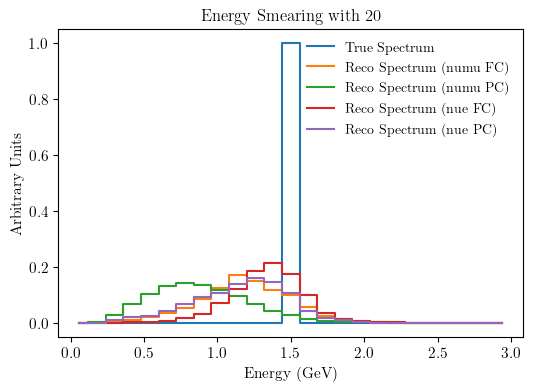

In [1993]:

# Plot the results
plt.figure(figsize=(6,4))


bin_centers = Etrue_bins[:-1] + np.diff(Etrue_bins)/2
true_spectrum = np.exp(-0.5 * ((bin_centers - 1.5)/0.01)**2)
plt.step(bin_centers, true_spectrum, where='mid', label='True Spectrum')

reco_spectrum = M_numuCC_FC_small.dot(true_spectrum)
plt.step(bin_centers, reco_spectrum, where='mid', label='Reco Spectrum (numu FC)')
print(true_spectrum.sum(), reco_spectrum.sum())

reco_spectrum = M_numuCC_PC_small.dot(true_spectrum)
plt.step(bin_centers, reco_spectrum, where='mid', label='Reco Spectrum (numu PC)')
print(true_spectrum.sum(), reco_spectrum.sum())


reco_spectrum = M_nueCC_FC_small.dot(true_spectrum)
plt.step(bin_centers, reco_spectrum, where='mid', label='Reco Spectrum (nue FC)')
print(true_spectrum.sum(), reco_spectrum.sum())


reco_spectrum = M_nueCC_PC_small.dot(true_spectrum)
plt.step(bin_centers, reco_spectrum, where='mid', label='Reco Spectrum (nue PC)')
print(true_spectrum.sum(), reco_spectrum.sum())


plt.xlabel('Energy (GeV)')
plt.ylabel('Arbitrary Units')
plt.title('Energy Smearing with 20% Resolution')
plt.legend()
# plt.ylim(0,0.0001)

## Building our covariance Matrix

In [1999]:
import OscTools as micro

SAMPLE = "FC"
nue_other_bkg = np.load(micro.muB_inclusive_datarelease_path + f"nueCC_{SAMPLE}_Bkg.npy")
nue_intrinsic_bkg = np.load(micro.muB_inclusive_datarelease_path + f"nueCC_{SAMPLE}_Sig.npy")
nue_data_bkg = np.load(micro.muB_inclusive_datarelease_path + f"nueCC_{SAMPLE}_Obs.npy")
numu_other_bkg = np.load(micro.muB_inclusive_datarelease_path + f"numuCC_{SAMPLE}_Bkg.npy")
numu_intrinsic_bkg = np.load(micro.muB_inclusive_datarelease_path + f"numuCC_{SAMPLE}_Sig.npy")
numu_data_bkg = np.load(micro.muB_inclusive_datarelease_path + f"numuCC_{SAMPLE}_Obs.npy")

SBND_numu_other_bkg = numu_other_bkg * micro.rescale_micro_to_SBN('SBND')
SBND_numu_intrinsic_bkg = numu_intrinsic_bkg * micro.rescale_micro_to_SBN('SBND')
SBND_numu_data_bkg = numu_data_bkg * micro.rescale_micro_to_SBN('SBND')
SBND_nue_other_bkg = nue_other_bkg * micro.rescale_micro_to_SBN('SBND')
SBND_nue_intrinsic_bkg = nue_intrinsic_bkg * micro.rescale_micro_to_SBN('SBND')
SBND_nue_data_bkg = nue_data_bkg * micro.rescale_micro_to_SBN('SBND')

ICARUS_numu_other_bkg = numu_other_bkg * micro.rescale_micro_to_SBN('ICARUS')
ICARUS_numu_intrinsic_bkg = numu_intrinsic_bkg * micro.rescale_micro_to_SBN('ICARUS')
ICARUS_numu_data_bkg = numu_data_bkg * micro.rescale_micro_to_SBN('ICARUS')
ICARUS_nue_other_bkg = nue_other_bkg * micro.rescale_micro_to_SBN('ICARUS')
ICARUS_nue_intrinsic_bkg = nue_intrinsic_bkg * micro.rescale_micro_to_SBN('ICARUS')
ICARUS_nue_data_bkg = nue_data_bkg * micro.rescale_micro_to_SBN('ICARUS')

AttributeError: module 'OscTools' has no attribute 'muB_inclusive_datarelease_path'

In [1998]:
import numpy as np

# Define the number of energy bins
num_bins = 26  # Example: 10 energy bins

# Define the event rate vectors (example values)
nue_SBND = SBND_nue_intrinsic_bkg + SBND_nue_other_bkg  # Example event rates for nu_e at SBND
nue_ICARUS = ICARUS_nue_intrinsic_bkg + ICARUS_nue_other_bkg  # Example event rates for nu_e at ICARUS
numu_SBND = SBND_numu_intrinsic_bkg + SBND_numu_other_bkg  # Example event rates for nu_mu at SBND
numu_ICARUS = ICARUS_numu_intrinsic_bkg + ICARUS_numu_other_bkg # Example event rates for nu_mu at ICARUS

# Combine the event rate vectors into a single vector
event_rates = np.concatenate([nue_SBND, nue_ICARUS, numu_SBND, numu_ICARUS])
data_event_rates = np.concatenate([SBND_nue_data_bkg, ICARUS_nue_data_bkg, SBND_numu_data_bkg, ICARUS_numu_data_bkg])

# Define the systematic uncertainties as energy-dependent (one value per energy bin)
delta_eta_flux = np.ones(num_bins)*0.10  # 10% flux uncertainty per bin
delta_eta_xsec = np.ones(num_bins)*0.10  # 10% cross-section uncertainty per bin
delta_eta_eff = np.ones(num_bins)*0.03  #3% detector efficiency uncertainty per bin

# Initialize the covariance matrix
num_rates = len(event_rates)
frac_cov_matrix = np.zeros((num_rates, num_rates))

# Function to add systematic uncertainty contributions to the covariance matrix
def add_systematic_uncertainty(frac_cov_matrix, delta_eta, correlated_indices):
    for i in correlated_indices:
        for j in correlated_indices:
            # Use the same delta_eta for the same energy bin (uncorrelated between bins)
            bin_i = i % num_bins  # Energy bin index for event i
            bin_j = j % num_bins  # Energy bin index for event j
            # if i>12:
                # print(i, j, bin_i, bin_j)
            if bin_i == bin_j:  # Only correlate within the same energy bin
                frac_cov_matrix[i, j] += (delta_eta[bin_i]) * (delta_eta[bin_j])

# Add flux uncertainty (correlated between SBND and ICARUS for the same energy bin, but uncorrelated between nu_e and nu_mu)
add_systematic_uncertainty(frac_cov_matrix, delta_eta_flux, range(2*num_bins))  # nu_e SBND + nu_e ICARUS 
add_systematic_uncertainty(frac_cov_matrix, delta_eta_flux, range(2*num_bins, 4*num_bins))  # nu_mu SBND + nu_mu ICARUS

# Add cross-section uncertainty (fully correlated between SBND, ICARUS, nu_e, and nu_mu for the same energy bin)
add_systematic_uncertainty(frac_cov_matrix, delta_eta_xsec, range(num_rates))

# # Add detector efficiency uncertainty (uncorrelated between detectors for the same energy bin)
add_systematic_uncertainty(frac_cov_matrix, delta_eta_eff, range(num_bins))  # nu_e SBND
add_systematic_uncertainty(frac_cov_matrix, delta_eta_eff, range(num_bins, 2 * num_bins))  # nu_e ICARUS
add_systematic_uncertainty(frac_cov_matrix, delta_eta_eff, range(2 * num_bins, 3 * num_bins))  # nu_mu SBND
add_systematic_uncertainty(frac_cov_matrix, delta_eta_eff, range(3 * num_bins, 4 * num_bins))  # nu_mu ICARUS

# Add statistical uncertainty (Poisson statistics)
statistical_uncertainty = np.sqrt(event_rates)/event_rates
frac_cov_matrix += np.diag(statistical_uncertainty**2)

cov_matrix = (event_rates*(frac_cov_matrix*event_rates).T).T
residuals = data_event_rates - event_rates  # Replace with (observed - predicted) if needed

# Calculate the chi2 statistic
inv_cov_matrix = np.linalg.inv(cov_matrix)  # Inverse of the covariance matrix

def SBN_Micro_chi2(residuals, inv_cov_matrix):
    return np.dot(residuals.T, np.dot(inv_cov_matrix, residuals))
    

NameError: name 'SBND_nue_intrinsic_bkg' is not defined

# Old Stuff

In [1638]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import crystalball


def build_smearing_matrix(Emin, Emax, nbins, resolution=0.2):
    """
    Build a migration/smearing matrix for neutrino energies using
    a Gaussian model with sigma = resolution * E_true.

    Parameters
    ----------
    Emin : float
        Minimum energy (GeV).
    Emax : float
        Maximum energy (GeV).
    nbins : int
        Number of bins (same for true and reco).
    resolution : float
        Fractional resolution (e.g. 0.2 means 20%).

    Returns
    -------
    M : (nbins, nbins) ndarray
        Smearing matrix. M[i, j] = Probability of migrating from true bin i
        to reco bin j.
    bin_centers : (nbins,) ndarray
        Centers of the energy bins.
    bin_edges : (nbins+1,) ndarray
        Edges of the energy bins.
    """

    # Define bin edges and centers
    bin_edges = np.linspace(Emin, Emax, nbins + 1)
    bin_widths = np.diff(bin_edges)  # for integration range
    bin_centers = bin_edges[:-1] + bin_widths/2

    # Prepare the smearing matrix
    M = np.zeros((nbins, nbins))

    # Build the matrix row by row: each row i corresponds to true energy bin i
    for i, E_true in enumerate(bin_centers):
        # Resolution sigma depends on E_true
        sigma = resolution * E_true

        # If E_true = 0, handle carefully to avoid sigma=0
        if sigma < 1e-12:
            sigma = 1e-12  # effectively no smearing

        # Construct row i by integrating Gaussian over each reco bin
        for j, E_center in enumerate(bin_centers):
            # We'll approximate the probability by the value of the integral
            # of the Gaussian pdf from bin_edges[j] to bin_edges[j+1]
            # Using scipy.stats.norm.cdf for the integral
            E_low = bin_edges[j]
            E_high = bin_edges[j+1]

            # Probability that reco-energy falls into bin j
            prob = norm.cdf((E_high - E_true)/sigma) - norm.cdf((E_low - E_true)/sigma)
            M[i, j] = prob

        # Normalize row i to sum to 1
        row_sum = M[i, :].sum()
        if row_sum > 0:
            M[i, :] /= row_sum

    return M.T, bin_centers, bin_edges


# Build the smearing matrix

# M, bin_centers, bin_edges = build_smearing_matrix(Emin=0, Emax=2, nbins=100, resolution=0.05)
M, bin_centers, bin_edges = build_smearing_matrix_crystal_ball(Emin=0, Emax=2, nbins=20, resolution=0.05, alpha=1.5, n=5)



true_spectrum = np.exp(-0.5 * ((bin_centers - 1)/0.01)**2)
reco_spectrum = M.dot(true_spectrum)

print(true_spectrum.sum(), reco_spectrum.sum())

# Plot the results
plt.figure(figsize=(8,6))
plt.step(bin_centers, true_spectrum, where='mid', label='True Spectrum')
plt.step(bin_centers, reco_spectrum, where='mid', label='Reco Spectrum (smeared)')
plt.xlabel('Energy (GeV)')
plt.ylabel('Arbitrary Units')
plt.title('Energy Smearing with 20% Resolution')
plt.legend()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59])

In [ ]:
import numpy as np

def build_sbn_covariance_matrix(
    ReS, ReI, RmS, RmI,
    flux_unc=0.10,   # 10% flux uncertainty
    xsec_unc=0.10,   # 10% cross-section uncertainty
    eff_unc=0.03     # 3% detector efficiency uncertainty
):
    """
    Build the (4N x 4N) covariance matrix for N energy bins.
    
    Parameters
    ----------
    ReS : array_like, length N
        Nominal rate predictions for nu_e at SBND in each energy bin.
    ReI : array_like, length N
        Nominal rate predictions for nu_e at ICARUS in each energy bin.
    RmS : array_like, length N
        Nominal rate predictions for nu_mu at SBND in each energy bin.
    RmI : array_like, length N
        Nominal rate predictions for nu_mu at ICARUS in each energy bin.
    flux_unc : float
        Fractional uncertainty (std dev) for the flux nuisance parameters (nu_e or nu_mu).
    xsec_unc : float
        Fractional uncertainty (std dev) for the cross-section parameter.
    eff_unc : float
        Fractional uncertainty (std dev) for the (uncorrelated) detector efficiency parameter.
        
    Returns
    -------
    cov : 2D numpy array, shape (4N, 4N)
        The covariance matrix encoding all flux, cross-section, and efficiency
        systematics described above.
    """
    
    # Number of bins
    N = len(ReS)
    
    # Initialize covariance matrix (4N x 4N) to zero
    cov = np.zeros((4*N, 4*N))
    
    # Loop over energy bins
    for i in range(N):
        
        # Indices in the big 4N-vector
        idx_eS = 4*i + 0  # nu_e @ SBND
        idx_eI = 4*i + 1  # nu_e @ ICARUS
        idx_mS = 4*i + 2  # nu_mu @ SBND
        idx_mI = 4*i + 3  # nu_mu @ ICARUS
        
        # Nominal rates in bin i
        ReS0 = ReS[i]
        ReI0 = ReI[i]
        RmS0 = RmS[i]
        RmI0 = RmI[i]
        
        #-------------------------------------------------------
        # 1) Flux nuisance param for nu_e in bin i
        #    (fully correlated across detectors, but
        #     does not affect nu_mu)
        #-------------------------------------------------------
        sigma_flux_e = flux_unc  # 10% by default
        # partial derivatives for each rate w.r.t. eta_{Phi_e}(E_i)
        dReS_dPhiE = ReS0  # affects nu_e @ SBND
        dReI_dPhiE = ReI0  # affects nu_e @ ICARUS
        dRmS_dPhiE = 0.0   # no effect on nu_mu
        dRmI_dPhiE = 0.0
        
        # Fill the sub-block for the flux-e correlation
        cov[idx_eS, idx_eS] += (dReS_dPhiE**2) * (sigma_flux_e**2)
        cov[idx_eS, idx_eI] += dReS_dPhiE * dReI_dPhiE * (sigma_flux_e**2)
        cov[idx_eI, idx_eS] += dReI_dPhiE * dReS_dPhiE * (sigma_flux_e**2)
        cov[idx_eI, idx_eI] += (dReI_dPhiE**2) * (sigma_flux_e**2)
        # (Since RmS and RmI don't depend on Phi_e, no fill-in for them)
        
        #-------------------------------------------------------
        # 2) Flux nuisance param for nu_mu in bin i
        #    (fully correlated across detectors, but
        #     does not affect nu_e)
        #-------------------------------------------------------
        sigma_flux_m = flux_unc  # 10% by default
        # partial derivatives w.r.t. eta_{Phi_mu}(E_i)
        dReS_dPhiM = 0.0
        dReI_dPhiM = 0.0
        dRmS_dPhiM = RmS0
        dRmI_dPhiM = RmI0
        
        # Fill the sub-block for the flux-mu correlation
        cov[idx_mS, idx_mS] += (dRmS_dPhiM**2) * (sigma_flux_m**2)
        cov[idx_mS, idx_mI] += dRmS_dPhiM * dRmI_dPhiM * (sigma_flux_m**2)
        cov[idx_mI, idx_mS] += dRmI_dPhiM * dRmS_dPhiM * (sigma_flux_m**2)
        cov[idx_mI, idx_mI] += (dRmI_dPhiM**2) * (sigma_flux_m**2)
        
        #-------------------------------------------------------
        # 3) Cross-section nuisance param (fully correlated
        #    across *all* flavors and detectors)
        #-------------------------------------------------------
        sigma_xsec = xsec_unc  # 10%
        # partial derivatives w.r.t. eta_sigma(E_i)
        dReS_dSigma = ReS0
        dReI_dSigma = ReI0
        dRmS_dSigma = RmS0
        dRmI_dSigma = RmI0
        
        # We'll fill in the 4x4 block (eS, eI, mS, mI) for this bin
        # with outer product of the derivative vector [ReS0, ReI0, RmS0, RmI0]
        # scaled by sigma_xsec^2.
        
        d_vec = np.array([dReS_dSigma, dReI_dSigma, dRmS_dSigma, dRmI_dSigma])
        block = np.outer(d_vec, d_vec) * (sigma_xsec**2)
        
        # Insert that 4x4 block into the big covariance
        idx_list = [idx_eS, idx_eI, idx_mS, idx_mI]
        for row_loc, row_idx in enumerate(idx_list):
            for col_loc, col_idx in enumerate(idx_list):
                cov[row_idx, col_idx] += block[row_loc, col_loc]
        
        #-------------------------------------------------------
        # 4) Detector-uncorrelated efficiency param for SBND
        #    (affects only eS and mS in bin i)
        #-------------------------------------------------------
        sigma_eff = eff_unc  # 3%
        dReS_dEffS = ReS0  # eS depends on SBND efficiency
        dReI_dEffS = 0.0   # eI does not
        dRmS_dEffS = RmS0  # mS depends on SBND efficiency
        dRmI_dEffS = 0.0
        
        # The relevant sub-block is just for (eS, mS)
        # partial-derivative vector for SBND efficiency = [ReS0, 0, RmS0, 0]
        d_vec_sbnd = np.array([dReS_dEffS, dReI_dEffS,
                               dRmS_dEffS, dRmI_dEffS])
        block_sbnd = np.outer(d_vec_sbnd, d_vec_sbnd) * (sigma_eff**2)
        # Insert into covariance
        for row_loc, row_idx in enumerate(idx_list):
            for col_loc, col_idx in enumerate(idx_list):
                cov[row_idx, col_idx] += block_sbnd[row_loc, col_loc]
        
        #-------------------------------------------------------
        # 5) Detector-uncorrelated efficiency param for ICARUS
        #    (affects only eI and mI in bin i)
        #-------------------------------------------------------
        dReS_dEffI = 0.0
        dReI_dEffI = ReI0
        dRmS_dEffI = 0.0
        dRmI_dEffI = RmI0
        
        d_vec_icarus = np.array([dReS_dEffI, dReI_dEffI,
                                 dRmS_dEffI, dRmI_dEffI])
        block_icarus = np.outer(d_vec_icarus, d_vec_icarus) * (sigma_eff**2)
        for row_loc, row_idx in enumerate(idx_list):
            for col_loc, col_idx in enumerate(idx_list):
                cov[row_idx, col_idx] += block_icarus[row_loc, col_loc]
        
        # Done with this bin's contributions to Cov

    # End of loop over energy bins
    return cov

# ---------------------------------------------------------
# Example usage:
if __name__ == "__main__":

    # Suppose we have N=3 energy bins, and the nominal
    # predicted rates for each channel are as follows:
    ReS = np.array([100., 120., 130.])  # nu_e @ SBND
    ReI = np.array([ 80.,  90., 100.])  # nu_e @ ICARUS
    RmS = np.array([500., 520., 550.])  # nu_mu @ SBND
    RmI = np.array([400., 410., 430.])  # nu_mu @ ICARUS

    cov_matrix = build_sbn_covariance_matrix(ReS, ReI, RmS, RmI)
    print("Covariance matrix shape:", cov_matrix.shape)
    print("Covariance matrix:\n", cov_matrix)